In [53]:
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
cust=pd.read_csv("C:/Nithish/al india/python/assignment/Python Foundation Case Study 1 - Retail Case Study/Case Study 1 - Retail Case Study/Customer.csv")

In [55]:
trans=pd.read_csv("C:/Nithish/al india/python/assignment/Python Foundation Case Study 1 - Retail Case Study/Case Study 1 - Retail Case Study/Transactions.csv")

In [56]:
prod=pd.read_csv("C:/Nithish/al india/python/assignment/Python Foundation Case Study 1 - Retail Case Study/Case Study 1 - Retail Case Study/prod_cat_info.csv")

In [57]:
cust.head()


,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0


In [58]:
trans.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop


In [59]:
prod.head()

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women


1. Merge the datasets Customers, Product Hierarchy and Transactions as Customer_Final.
Ensure to keep all customers who have done transactions with us and select the join type accordingly.

In [60]:
cust1=pd.merge(left=trans,right=cust,how='left',left_on='cust_id',right_on='customer_Id')
cust1

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,271509,08-06-1981,M,3.0
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,274550,21-02-1972,M,7.0
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,270022,27-04-1984,M,9.0
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,271020,20-06-1976,M,8.0
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,270911,22-05-1970,M,2.0


In [61]:
customer_final=pd.merge(left=cust1,right=prod,how='left',left_on=['prod_subcat_code','prod_cat_code'],right_on=['prod_sub_cat_code','prod_cat_code'])
customer_final.head(3)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,1,Women
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,5,Computers
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY


2. Prepare a summary report for the merged data set.

a. Get the column names and their corresponding data types
b. Top/Bottom 10 observations
c. “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)
d. Frequency tables for all the categorical variables

a. Get the column names and their corresponding data types

In [62]:
customer_final.dtypes

transaction_id         int64
cust_id                int64
tran_date             object
prod_subcat_code       int64
prod_cat_code          int64
Qty                    int64
Rate                   int64
Tax                  float64
total_amt            float64
Store_type            object
customer_Id            int64
DOB                   object
Gender                object
city_code            float64
prod_cat              object
prod_sub_cat_code      int64
prod_subcat           object
dtype: object

b. Top/Bottom 10 observations

In [63]:
customer_final.head(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,1,Women
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,5,Computers
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,271509,08-06-1981,M,3.0,Home and kitchen,11,Bath
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY
5,97439039119,272357,23-02-2014,8,3,-2,-824,173.040,-1821.040,TeleShop,272357,09-10-1982,F,6.0,Electronics,8,Personal Appliances
6,45649838090,273667,22-02-2014,11,6,-1,-1450,152.250,-1602.250,e-Shop,273667,29-05-1981,M,9.0,Home and kitchen,11,Bath
7,22643667930,271489,22-02-2014,12,6,-1,-1225,128.625,-1353.625,TeleShop,271489,21-04-1971,M,9.0,Home and kitchen,12,Tools
8,79792372943,275108,22-02-2014,3,1,-3,-908,286.020,-3010.020,MBR,275108,04-11-1971,F,8.0,Clothing,3,Kids
9,50076728598,269014,21-02-2014,8,3,-4,-581,244.020,-2568.020,e-Shop,269014,27-11-1979,F,3.0,Electronics,8,Personal Appliances


In [64]:
customer_final.tail(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
23043,49882891062,271982,25-01-2011,10,5,4,1330,558.600,5878.600,e-Shop,271982,10-08-1976,M,8.0,Books,10,Non-Fiction
23044,14787475597,273982,25-01-2011,4,3,5,969,508.725,5353.725,e-Shop,273982,12-10-1991,M,4.0,Electronics,4,Mobiles
23045,50691119572,273031,25-01-2011,6,5,1,1148,120.540,1268.540,TeleShop,273031,17-01-1980,F,8.0,Books,6,DIY
23046,40893803228,272049,25-01-2011,11,6,3,1077,339.255,3570.255,e-Shop,272049,28-06-1975,F,6.0,Home and kitchen,11,Bath
23047,30856003613,266866,25-01-2011,4,2,2,444,93.240,981.240,TeleShop,266866,18-04-1974,M,4.0,Footwear,4,Kids
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,274550,21-02-1972,M,7.0,Books,12,Academic
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,270022,27-04-1984,M,9.0,Clothing,4,Mens
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,271020,20-06-1976,M,8.0,Home and kitchen,2,Furnishing
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,270911,22-05-1970,M,2.0,Books,11,Children
23052,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,271961,15-01-1982,M,1.0,Books,11,Children


c. “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)

In [65]:
Five_number_summary=customer_final.describe().T
Five_number_summary

,count,mean,std,min,25%,50%,75%,max
transaction_id,23053.0,5.007348e+10,2.898194e+10,3268991.000,2.493864e+10,5.009313e+10,7.533000e+10,9.998755e+10
cust_id,23053.0,2.710217e+05,2.431692e+03,266783.000,2.689350e+05,2.709800e+05,2.731140e+05,2.752650e+05
prod_subcat_code,23053.0,6.149091e+00,3.726372e+00,1.000,3.000000e+00,5.000000e+00,1.000000e+01,1.200000e+01
prod_cat_code,23053.0,3.763632e+00,1.677016e+00,1.000,2.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Qty,23053.0,2.432395e+00,2.268406e+00,-5.000,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Rate,23053.0,6.363697e+02,6.223635e+02,-1499.000,3.120000e+02,7.100000e+02,1.109000e+03,1.500000e+03
Tax,23053.0,2.486672e+02,1.871778e+02,7.350,9.828000e+01,1.990800e+02,3.657150e+02,7.875000e+02
total_amt,23053.0,2.107308e+03,2.507561e+03,-8270.925,7.624500e+02,1.754740e+03,3.569150e+03,8.287500e+03
customer_Id,23053.0,2.710217e+05,2.431692e+03,266783.000,2.689350e+05,2.709800e+05,2.731140e+05,2.752650e+05
city_code,23045.0,5.482534e+00,2.863499e+00,1.000,3.000000e+00,5.000000e+00,8.000000e+00,1.000000e+01


d. Frequency tables for all the categorical variables

In [66]:
customer_final.value_counts()

transaction_id  cust_id  tran_date   prod_subcat_code  prod_cat_code  Qty  Rate   Tax      total_amt  Store_type      customer_Id  DOB         Gender  city_code  prod_cat          prod_sub_cat_code  prod_subcat
44125492691     274748   19-12-2011  3                 2              -5   -767   402.675  -4237.675  e-Shop          274748       22-06-1991  M       1.0        Footwear          3                  Women          2
84298959416     268663   22-04-2012  3                 5              -2   -321   67.410   -709.410   TeleShop        268663       17-05-1975  F       8.0        Books             3                  Comics         2
98271941861     267939   29-06-2011  10                5              -4   -1238  519.960  -5471.960  Flagship store  267939       18-03-1985  F       1.0        Books             10                 Non-Fiction    2
48727689115     270330   21-10-2012  4                 3              -4   -1158  486.360  -5118.360  TeleShop        270330       13-07-1981

In [67]:
# Select only the columns that contain text/categories
categorical_cols = customer_final.select_dtypes(include=['object']).columns

# Loop and print the frequency table for each one
for col in categorical_cols:
    print(f"--- Frequency Table for {col} ---")
    print(customer_final[col].value_counts())
    print("\n")


--- Frequency Table for tran_date ---
tran_date
13-07-2011    35
21-12-2013    33
23-10-2011    33
22-11-2011    33
25-09-2011    33
              ..
23-02-2014     2
24-02-2014     2
27-02-2014     1
21-02-2014     1
28-02-2014     1
Name: count, Length: 1129, dtype: int64


--- Frequency Table for Store_type ---
Store_type
e-Shop            9311
MBR               4661
Flagship store    4577
TeleShop          4504
Name: count, dtype: int64


--- Frequency Table for DOB ---
DOB
27-12-1988    32
17-09-1982    32
25-02-1974    27
20-03-1972    25
18-11-1991    24
              ..
29-01-1976     1
01-05-1980     1
23-06-1988     1
25-06-1985     1
10-06-1972     1
Name: count, Length: 3987, dtype: int64


--- Frequency Table for Gender ---
Gender
M    11811
F    11233
Name: count, dtype: int64


--- Frequency Table for prod_cat ---
prod_cat
Books               6069
Electronics         4898
Home and kitchen    4129
Footwear            2999
Clothing            2960
Bags                1998


In [68]:
customer_final.tran_date.value_counts

<bound method IndexOpsMixin.value_counts of 0        28-02-2014
1        27-02-2014
2        24-02-2014
3        24-02-2014
4        23-02-2014
            ...    
23048    25-01-2011
23049    25-01-2011
23050    25-01-2011
23051    25-01-2011
23052    25-01-2011
Name: tran_date, Length: 23053, dtype: object>

In [69]:
categorical_column=customer_final.select_dtypes(include=['object']).columns
for col in categorical_column:
    print('frequency table')
    print(customer_final[col].value_counts())
    print('\n')

frequency table
tran_date
13-07-2011    35
21-12-2013    33
23-10-2011    33
22-11-2011    33
25-09-2011    33
              ..
23-02-2014     2
24-02-2014     2
27-02-2014     1
21-02-2014     1
28-02-2014     1
Name: count, Length: 1129, dtype: int64


frequency table
Store_type
e-Shop            9311
MBR               4661
Flagship store    4577
TeleShop          4504
Name: count, dtype: int64


frequency table
DOB
27-12-1988    32
17-09-1982    32
25-02-1974    27
20-03-1972    25
18-11-1991    24
              ..
29-01-1976     1
01-05-1980     1
23-06-1988     1
25-06-1985     1
10-06-1972     1
Name: count, Length: 3987, dtype: int64


frequency table
Gender
M    11811
F    11233
Name: count, dtype: int64


frequency table
prod_cat
Books               6069
Electronics         4898
Home and kitchen    4129
Footwear            2999
Clothing            2960
Bags                1998
Name: count, dtype: int64


frequency table
prod_subcat
Women                  3048
Mens             

3. Generate histograms for all continuous variables and frequency bars for categorical variables.

In [70]:
customer_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23053 entries, 0 to 23052
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     23053 non-null  int64  
 1   cust_id            23053 non-null  int64  
 2   tran_date          23053 non-null  object 
 3   prod_subcat_code   23053 non-null  int64  
 4   prod_cat_code      23053 non-null  int64  
 5   Qty                23053 non-null  int64  
 6   Rate               23053 non-null  int64  
 7   Tax                23053 non-null  float64
 8   total_amt          23053 non-null  float64
 9   Store_type         23053 non-null  object 
 10  customer_Id        23053 non-null  int64  
 11  DOB                23053 non-null  object 
 12  Gender             23044 non-null  object 
 13  city_code          23045 non-null  float64
 14  prod_cat           23053 non-null  object 
 15  prod_sub_cat_code  23053 non-null  int64  
 16  prod_subcat        230

In [71]:

def distribution(x):
    plt.figure(figsize=(17,5))
    plt.title('data distribution of' + x.name)
    x.hist()
    plt.show()

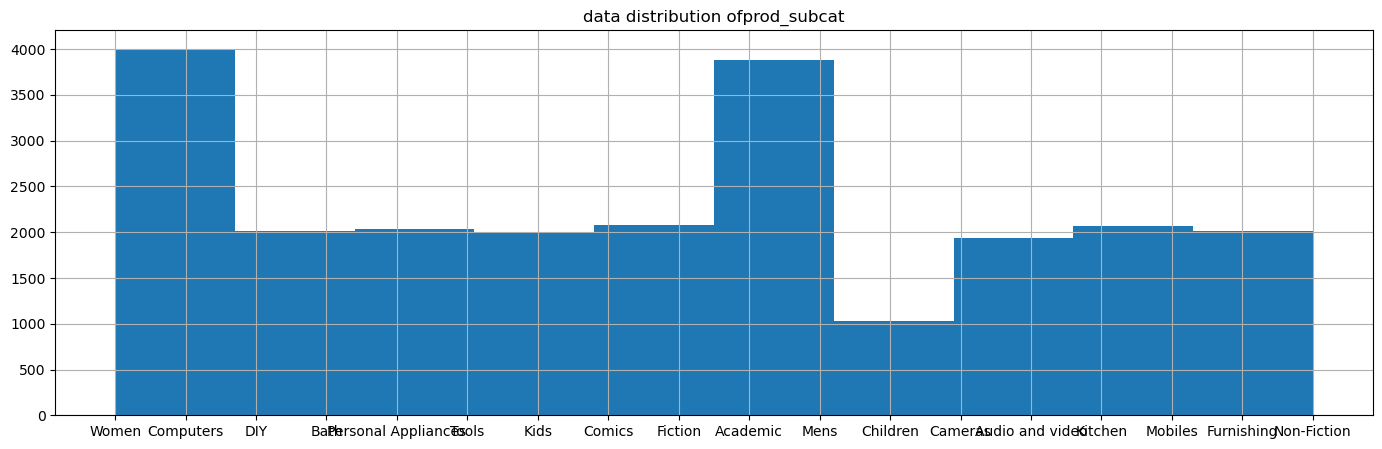

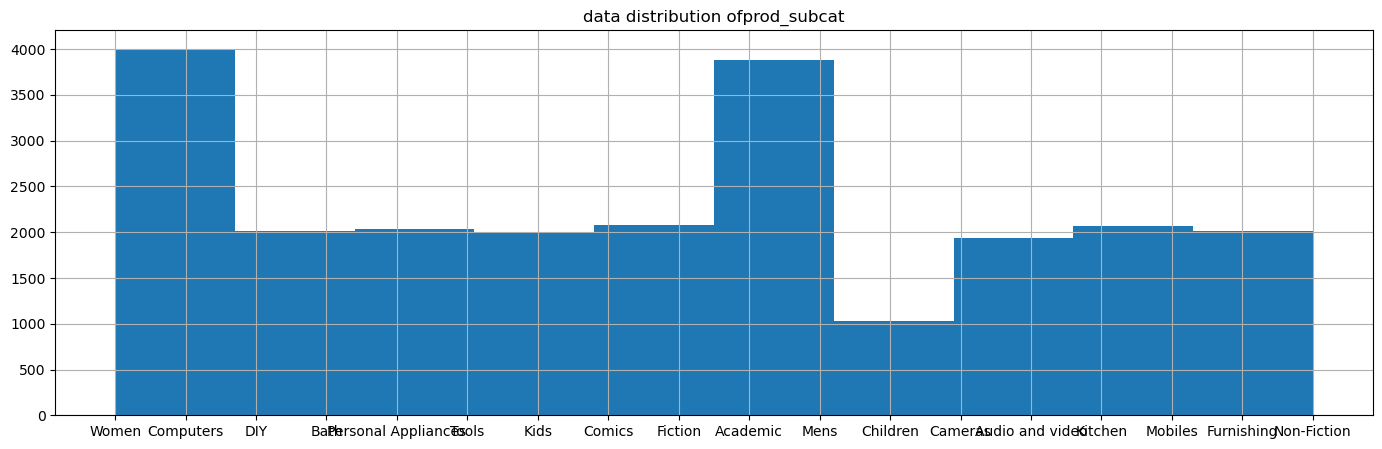

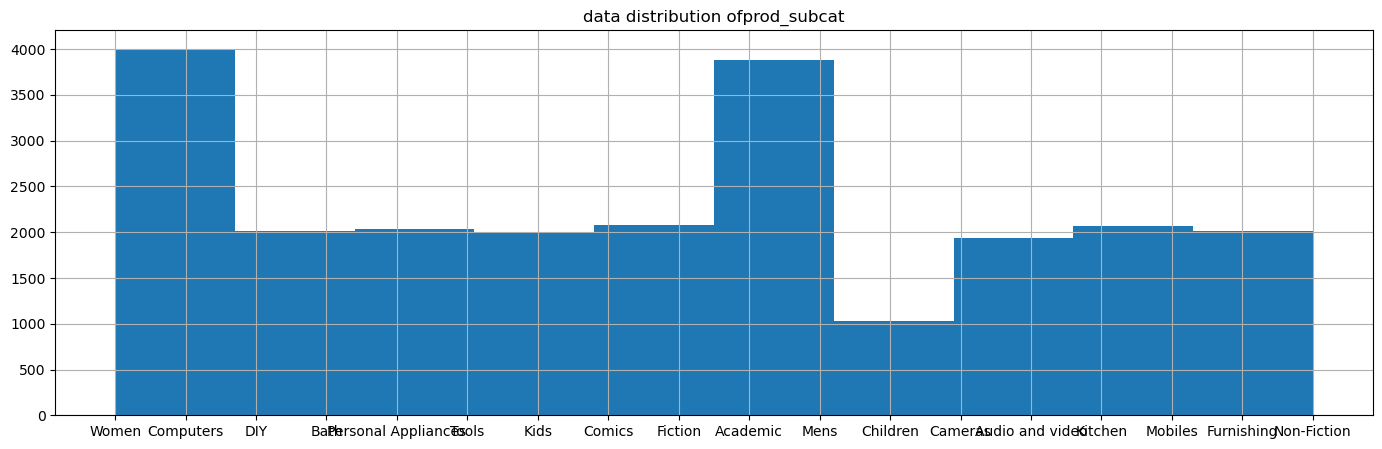

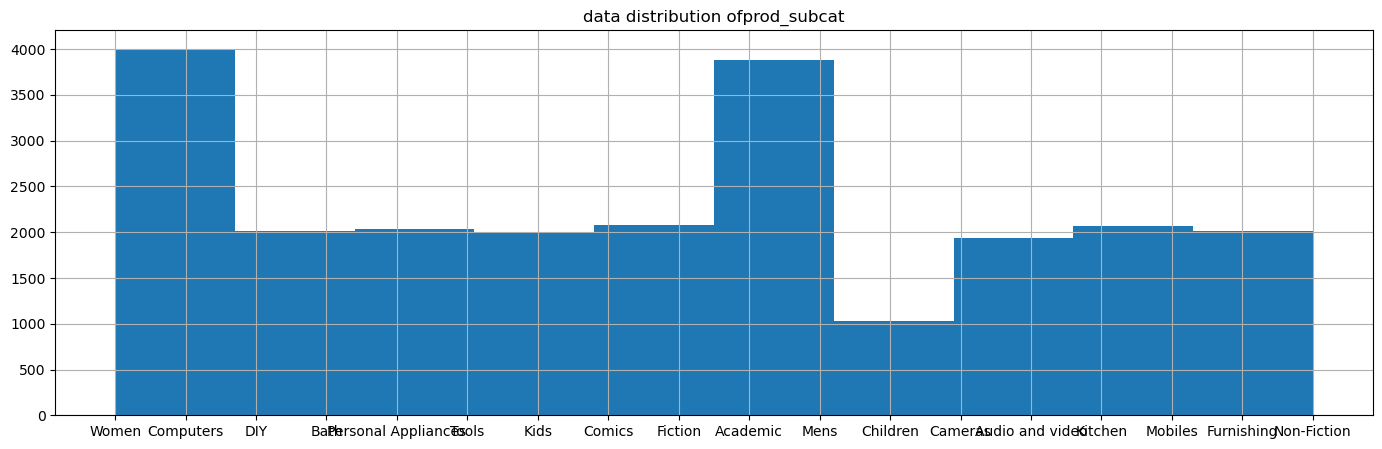

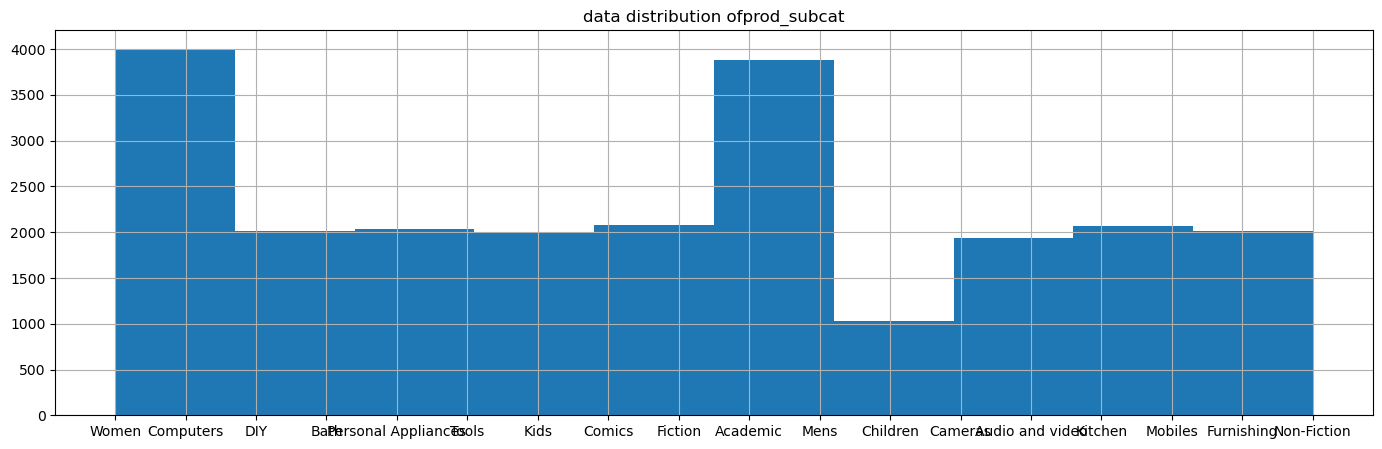

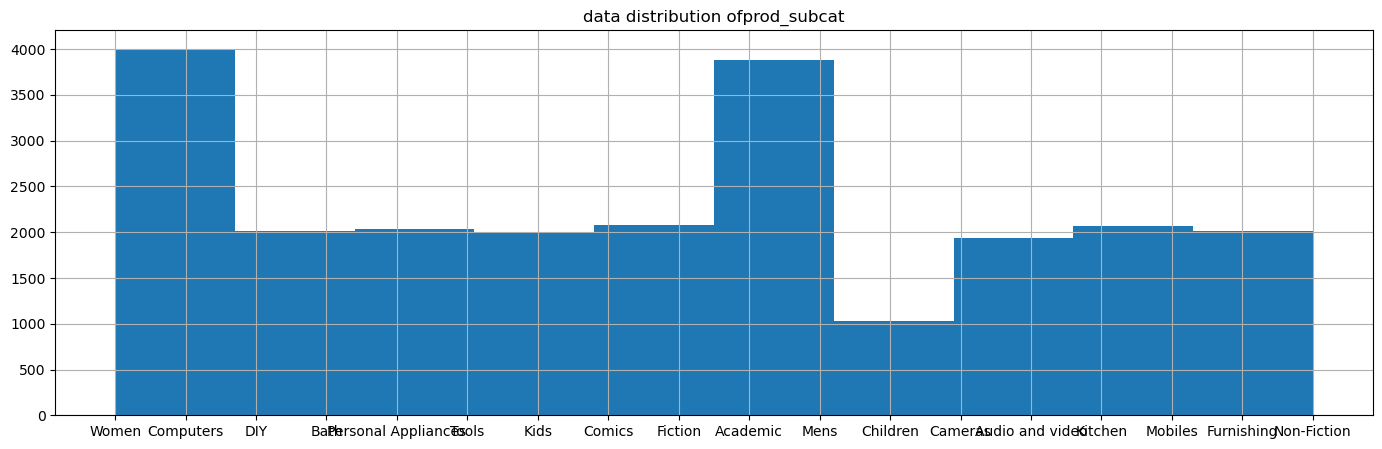

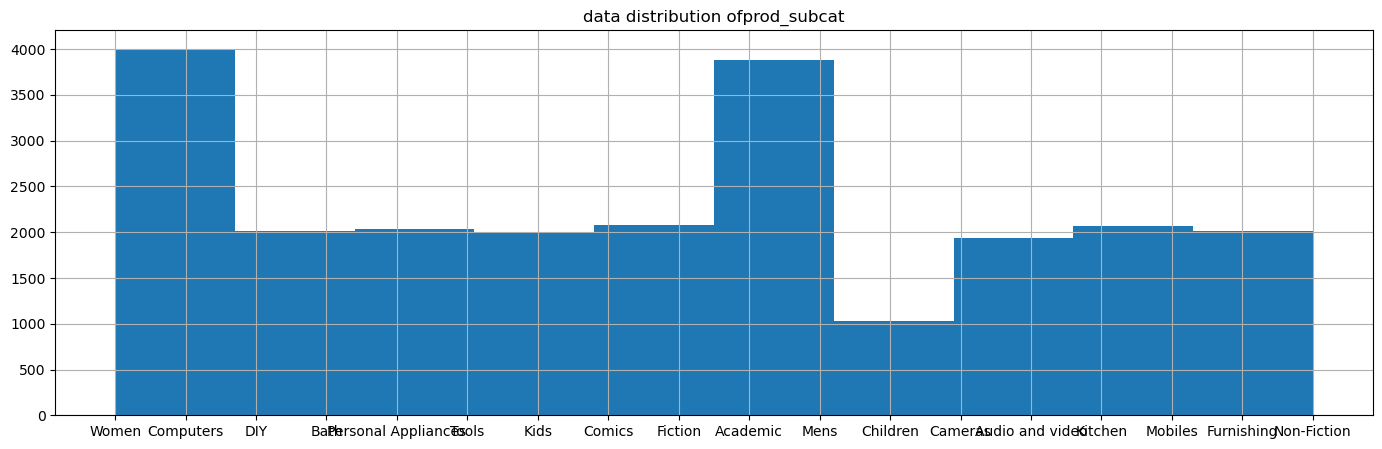

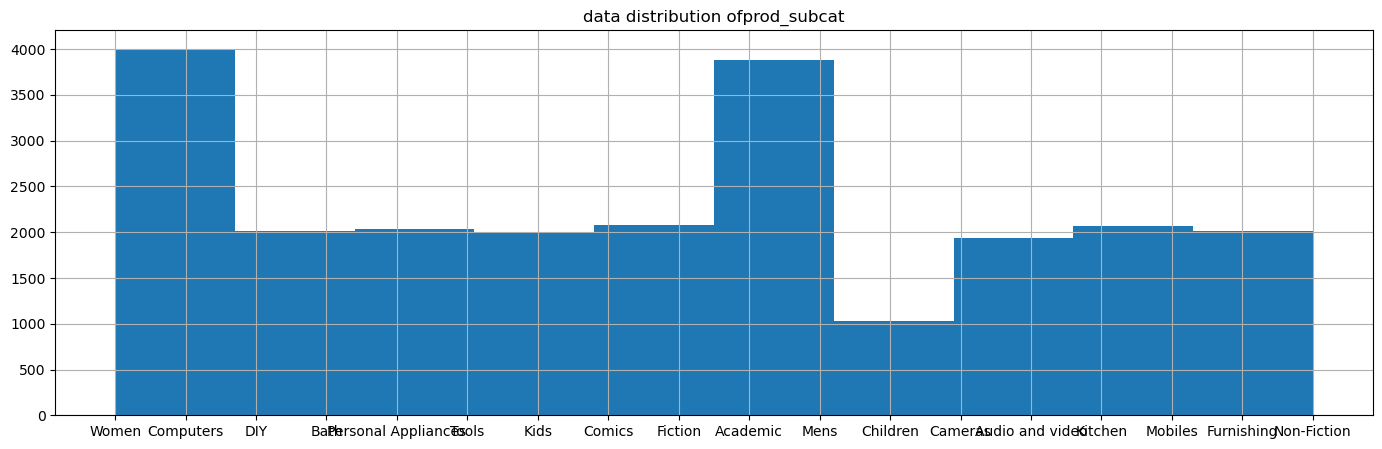

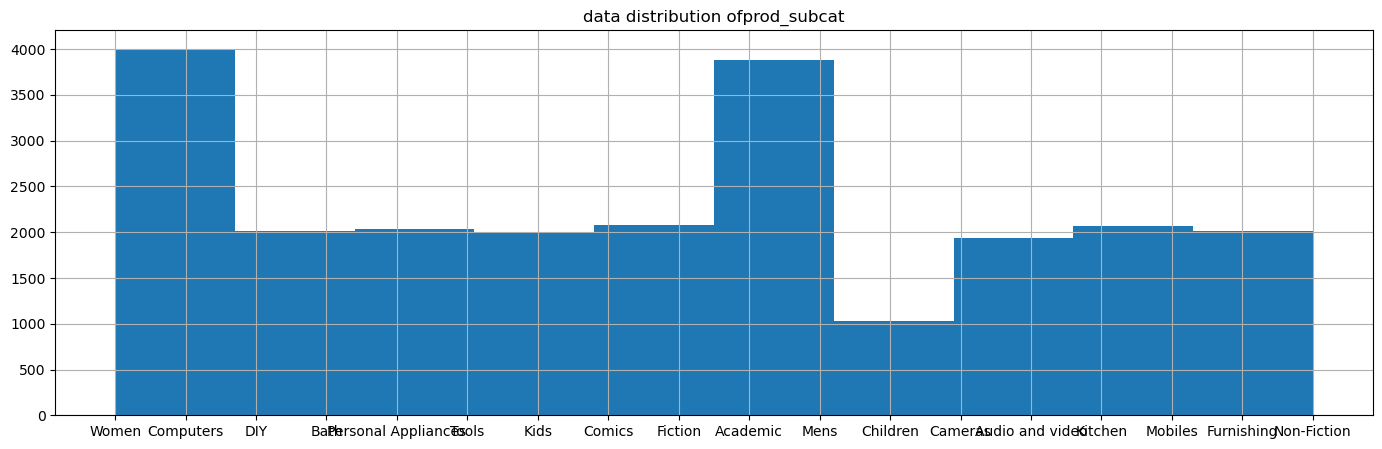

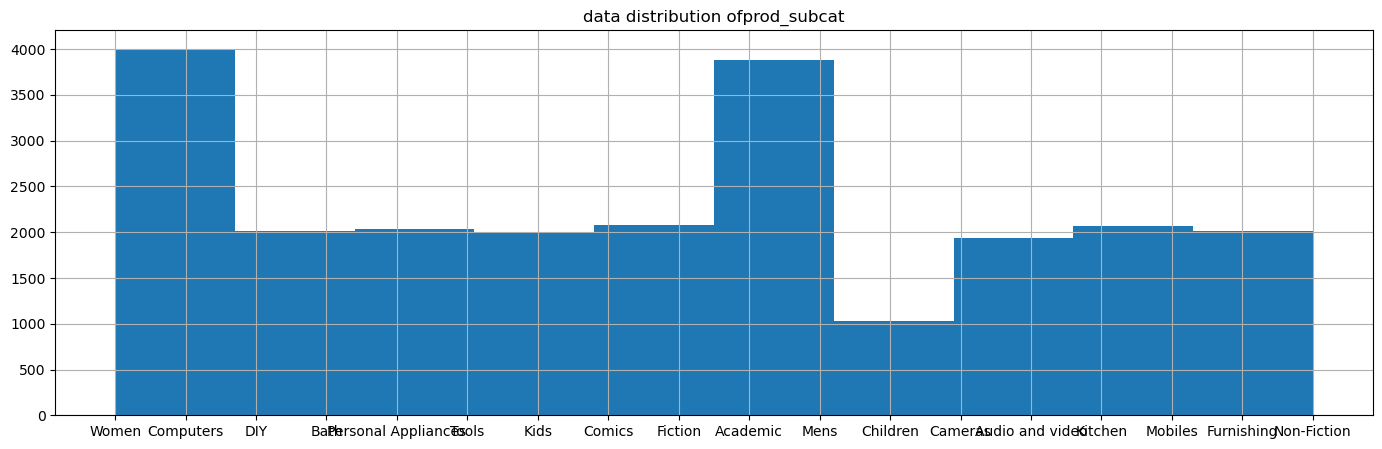

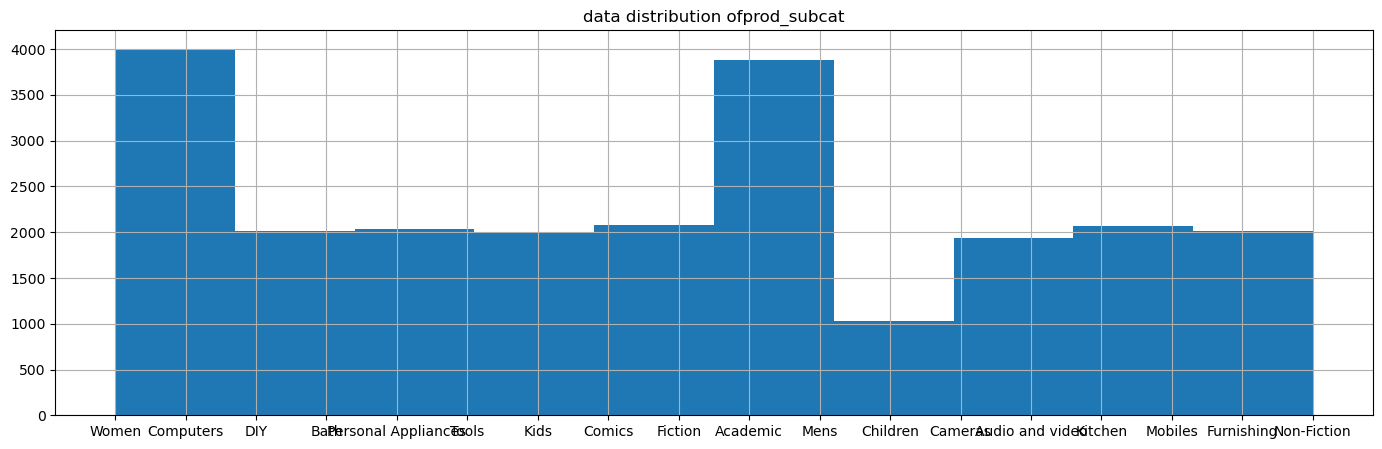

In [72]:
numeric_col=customer_final.select_dtypes(['int64','float64'])
for i in numeric_col.columns:
    distribution(customer_final[col])

4. Calculate the following information using the merged dataset :

a. Time period of the available transaction data
b. Count of transactions where the total amount of transaction was negative

a. Time period of the available transaction data

In [74]:
customer_final['tran_date']=pd.to_datetime(customer_final['tran_date'],format='%d-%m%-%Y')

In [77]:
customer_final['tran_date'].sort_values(ascending=True)

23052   2011-01-25
23033   2011-01-25
23034   2011-01-25
23035   2011-01-25
23036   2011-01-25
           ...    
4       2014-02-23
3       2014-02-24
2       2014-02-24
1       2014-02-27
0       2014-02-28
Name: tran_date, Length: 23053, dtype: datetime64[ns]

In [101]:
start_date=customer_final['tran_date'].min().strftime('%B %d, %Y')
end_date=customer_final['tran_date'].max().strftime('%B %d, %Y')
print(f"The transaction data covers the period from {start_date} to {end_date}.")

The transaction data covers the period from January 25, 2011 to February 28, 2014.


b. Count of transactions where the total amount of transaction was negative

5. Analyze which product categories are more popular among females vs male customers.

In [102]:
customer_final.prod_cat.unique()

array(['Clothing', 'Electronics', 'Books', 'Home and kitchen', 'Footwear',
       'Bags'], dtype=object)

In [103]:
pro_cat_comp=customer_final.groupby(['Gender','prod_cat'])['transaction_id'].count().reset_index()
pro_cat_comp

,Gender,prod_cat,transaction_id
0,F,Bags,994
1,F,Books,2949
2,F,Clothing,1439
3,F,Electronics,2328
4,F,Footwear,1529
5,F,Home and kitchen,1994
6,M,Bags,1004
7,M,Books,3116
8,M,Clothing,1518
9,M,Electronics,2570


6. Which City code has the maximum customers and what was the percentage of customers from
that city?

In [104]:
customer_final.head(2)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,1,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,5,Computers


In [105]:
count_cust_citycode=customer_final.groupby('city_code')['customer_Id'].nunique().reset_index()
count_cust_citycode['percentage']=count_cust_citycode['customer_Id']*100/count_cust_citycode['customer_Id'].sum()
count_cust_citycode.sort_values(by=['customer_Id','percentage'],ascending=False).head(1)

,city_code,customer_Id,percentage
2,3.0,576,10.465116


7. Which store type sells the maximum products by value and by quantity?

In [106]:
customer_final.Store_type.unique()

array(['e-Shop', 'TeleShop', 'MBR', 'Flagship store'], dtype=object)

In [107]:
summ=customer_final.groupby('Store_type')[ ['total_amt','Qty'] ].agg({'total_amt':'sum','Qty':'count'})
summ1=summ.rename(columns={'total_amt':'by_value'})
summ1['by_value']=summ1['by_value'].round(2)

summ1=summ1.sort_values(by=['by_value','Qty'],ascending=False)
summ1

,by_value,Qty
Store_type,,
e-Shop,19824816.05,9311
Flagship store,9715688.19,4577
MBR,9674486.06,4661
TeleShop,9364781.07,4504


In [108]:
customer_final.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,1,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,5,Computers
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,271509,08-06-1981,M,3.0,Home and kitchen,11,Bath
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY


8. What was the total amount earned from the "Electronics" and "Clothing" categories from
Flagship Stores?

In [109]:
filter_cat=customer_final.loc[(customer_final['prod_cat'].isin(['Electronics','Clothing'])) & (customer_final['Store_type']=='Flagship store')]
filter_cat_tot=filter_cat.groupby(['prod_cat','Store_type'])['total_amt'].sum().reset_index()
filter_cat_tot

,prod_cat,Store_type,total_amt
0,Clothing,Flagship store,1194423.23
1,Electronics,Flagship store,2215136.04


What was the total amount earned from "Male" customers under the "Electronics" category?

In [110]:
fil_cus=customer_final.loc[(customer_final['prod_cat']=='Electronics') & (customer_final['Gender']=='M') ]
fil_cus_tot=fil_cus.groupby('prod_cat')['total_amt'].sum()
fil_cus_tot=fil_cus_tot.round(2)
print('total amount by male from electronics cat=',fil_cus_tot)

total amount by male from electronics cat= prod_cat
Electronics    5703109.42
Name: total_amt, dtype: float64


In [111]:
customer_final.head(5)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,1,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,5,Computers
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,271509,08-06-1981,M,3.0,Home and kitchen,11,Bath
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY


10. How many customers have more than 10 unique transactions, after removing all transactions
which have any negative amounts?

In [112]:
fil_neg=customer_final.loc[customer_final.total_amt>0]
fil_neg_cus=fil_neg.groupby('cust_id')['transaction_id'].count()
fil_neg_cus_final=fil_neg_cus.loc[fil_neg_cus>10]
fil_neg_cus_final

cust_id
266794    11
270535    11
270803    11
272741    11
273014    11
274227    11
Name: transaction_id, dtype: int64

11. For all customers aged between 25 - 35, find out:

a. What was the total amount spent for “Electronics” and “Books” product categories?

In [136]:
cust['DOB']=pd.to_datetime(cust['DOB'],format='%d-%m-%Y')
cust['age']=(pd.Timestamp.now()-cust['DOB']).dt.days/365.25
cust['Age']=cust['age'].apply(np.floor)
cust.head(2)

,customer_Id,DOB,Gender,city_code,Age,age
0,268408,1970-01-02,M,4.0,56.0,56.449008
1,269696,1970-01-07,F,8.0,56.0,56.435318


In [137]:
cust.drop(columns=['age'],inplace=True)

In [138]:
cust1=pd.merge(left=trans,right=cust,how='left',left_on='cust_id',right_on='customer_Id')
cust1.head(1)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,Age
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.3,-4265.3,e-Shop,270351,1981-09-26,M,5.0,44.0


In [139]:
customer_final=pd.merge(left=cust1,right=prod,how='left',left_on=['prod_subcat_code','prod_cat_code'],right_on=['prod_sub_cat_code','prod_cat_code'])
customer_final.head(3)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,Age,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,1981-09-26,M,5.0,44.0,Clothing,1,Women
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,1973-05-11,F,8.0,53.0,Electronics,5,Computers
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,1992-07-27,M,8.0,33.0,Books,6,DIY


In [145]:
import pandas as pd

# Convert on the master DataFrame using mixed format parsing
customer_final['tran_date'] = pd.to_datetime(customer_final['tran_date'], format='mixed', dayfirst=True, errors='coerce')

In [146]:
cust_fil_prod=customer_final.loc[
    (customer_final['Age']>=25) & 
    (customer_final['Age']<=35) & 
    (customer_final['prod_cat'].isin(['Electonics','Books']))]
cust_fil_prod.head(3)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,Age,prod_cat,prod_sub_cat_code,prod_subcat
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.11,-1748.11,TeleShop,273420,1992-07-27,M,8.0,33.0,Books,6,DIY
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.11,-1748.11,TeleShop,273420,1992-07-27,M,8.0,33.0,Books,6,DIY
84,51750724947,273420,2014-02-16,6,5,2,791,166.11,1748.11,TeleShop,273420,1992-07-27,M,8.0,33.0,Books,6,DIY


b. What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014?

In [147]:
cust_fil_prod=customer_final.loc[
    (customer_final['Age']>=25) & 
    (customer_final['Age']<=35) & 
    (customer_final['prod_cat'].isin(['Electronics','Books']))]
cust_fil_prod.head(3)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,Age,prod_cat,prod_sub_cat_code,prod_subcat
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.11,-1748.11,TeleShop,273420,1992-07-27,M,8.0,33.0,Books,6,DIY
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.11,-1748.11,TeleShop,273420,1992-07-27,M,8.0,33.0,Books,6,DIY
59,83313344780,271288,2014-02-18,4,3,2,84,17.64,185.64,Flagship store,271288,1991-02-25,F,3.0,35.0,Electronics,4,Mobiles


In [155]:
date_fil=cust_fil_prod[cust_fil_prod['tran_date'].between('2014-01-01', '2014-03-01')]
print('total_amount=',date_fil['total_amt'].sum())

total_amount= 116504.56999999999
